# PART A: Synthetic Prototype Foundation

3.1 CORE DEPENDENCIES

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
import networkx as nx

3.2 SPATIAL GRID

In [2]:
class SpatialGrid:
    def __init__(self, width, height, cell_size=1):
        self.width = width
        self.height = height
        self.cell_size = cell_size

        # Base fields
        self.ici = np.zeros((height, width))
        self.elevation = np.zeros((height, width))
        self.land_type = np.zeros((height, width))  # placeholder categorical

    def seed_ici(self, mode="gaussian"):
        """Synthetic ICI field for v2 prototype."""
        if mode == "gaussian":
            cx, cy = self.width // 2, self.height // 2
            for y in range(self.height):
                for x in range(self.width):
                    dist = np.sqrt((x - cx)**2 + (y - cy)**2)
                    self.ici[y, x] = np.exp(-dist / 10)

3.3 ROAD GRAPH GENERATOR

In [3]:
class RoadGraph:
    def __init__(self):
        self.G = nx.Graph()

    def seed_center(self, x, y):
        self.G.add_node((x, y))

    def expand_grid_roads(self, grid, steps=10):
        """Simple deterministic expansion."""
        nodes = list(self.G.nodes)

        for _ in range(steps):
            new_nodes = []

            for (x, y) in nodes:
                candidates = [
                    (x + 1, y),
                    (x - 1, y),
                    (x, y + 1),
                    (x, y - 1)
                ]

                for nx_, ny_ in candidates:
                    if 0 <= nx_ < grid.width and 0 <= ny_ < grid.height:
                        if (nx_, ny_) not in self.G:
                            # ICI bias: higher probability of expansion in high intensity zones
                            prob = grid.ici[ny_, nx_]
                            if np.random.rand() < prob:
                                self.G.add_node((nx_, ny_))
                                self.G.add_edge((x, y), (nx_, ny_))
                                new_nodes.append((nx_, ny_))

            nodes = new_nodes

3.4 PARCEL GENERATION

In [4]:
class ParcelEngine:
    def __init__(self, road_graph):
        self.road_graph = road_graph
        self.parcels = []

    def generate_parcels(self):
        for node in self.road_graph.G.nodes:
            x, y = node

            neighbors = list(self.road_graph.G.neighbors(node))
            if len(neighbors) >= 2:
                parcel = {
                    "center": (x, y),
                    "connectivity": len(neighbors),
                    "area_proxy": len(neighbors) * 10
                }
                self.parcels.append(parcel)

3.5 CONSTRAINT FIELD (ENGINEERING LAYER)

In [5]:
class ConstraintField:
    def __init__(self, grid):
        self.grid = grid
        self.slope_limit = 0.3

    def compute_slope(self, x, y):
        # simplified gradient approximation
        gx = abs(self.grid.elevation[y, x] - self.grid.elevation[y, max(0, x-1)])
        gy = abs(self.grid.elevation[y, x] - self.grid.elevation[max(0, y-1), x])
        return gx + gy

    def is_buildable(self, x, y):
        slope = self.compute_slope(x, y)
        return slope < self.slope_limit

3.6 ICI-DRIVEN URBAN STATE MODEL

In [6]:
class UrbanState:
    def __init__(self, grid, road_graph, parcels, constraints):
        self.grid = grid
        self.road_graph = road_graph
        self.parcels = parcels
        self.constraints = constraints

    def summary(self):
        return {
            "roads": len(self.road_graph.G.nodes),
            "parcels": len(self.parcels),
            "mean_ici": np.mean(self.grid.ici)
        }

3.7 FULL PIPELINE DEMO (MINIMAL EXECUTION)

In [7]:
# Initialize grid
grid = SpatialGrid(50, 50)
grid.seed_ici()

# Road system
roads = RoadGraph()
roads.seed_center(25, 25)
roads.expand_grid_roads(grid, steps=20)

# Parcels
parcel_engine = ParcelEngine(roads)
parcel_engine.generate_parcels()

# Constraints
constraints = ConstraintField(grid)

# Urban state
state = UrbanState(grid, roads, parcel_engine.parcels, constraints)

print(state.summary())

{'roads': 272, 'parcels': 184, 'mean_ici': np.float64(0.19231150906903524)}


4.1 ICI HEATMAP

In [8]:
def plot_ici_field(grid):
    plt.figure(figsize=(8, 8))

    plt.imshow(
        grid.ici,
        cmap="inferno",
        origin="lower"
    )

    plt.colorbar(label="ICI Intensity")

    plt.title("ICI Spatial Intensity Field")
    plt.xlabel("X")
    plt.ylabel("Y")

    plt.tight_layout()
    plt.show()

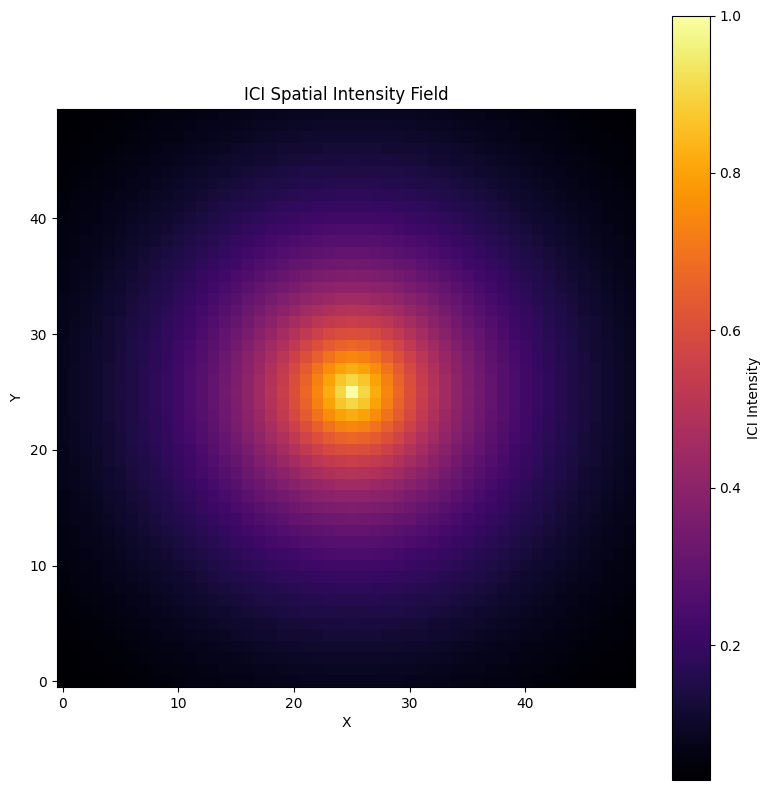

In [9]:
plot_ici_field(grid)

4.2 ROAD NETWORK VISUALIZATION

In [10]:
def plot_road_graph(grid, road_graph):
    plt.figure(figsize=(8, 8))

    # Background intensity field
    plt.imshow(
        grid.ici,
        cmap="gray",
        alpha=0.35,
        origin="lower"
    )

    # Road edges
    for edge in road_graph.G.edges:
        (x1, y1), (x2, y2) = edge

        plt.plot(
            [x1, x2],
            [y1, y2],
            linewidth=1.5
        )

    plt.title("ICI-Driven Procedural Road Expansion")
    plt.xlabel("X")
    plt.ylabel("Y")

    plt.tight_layout()
    plt.show()

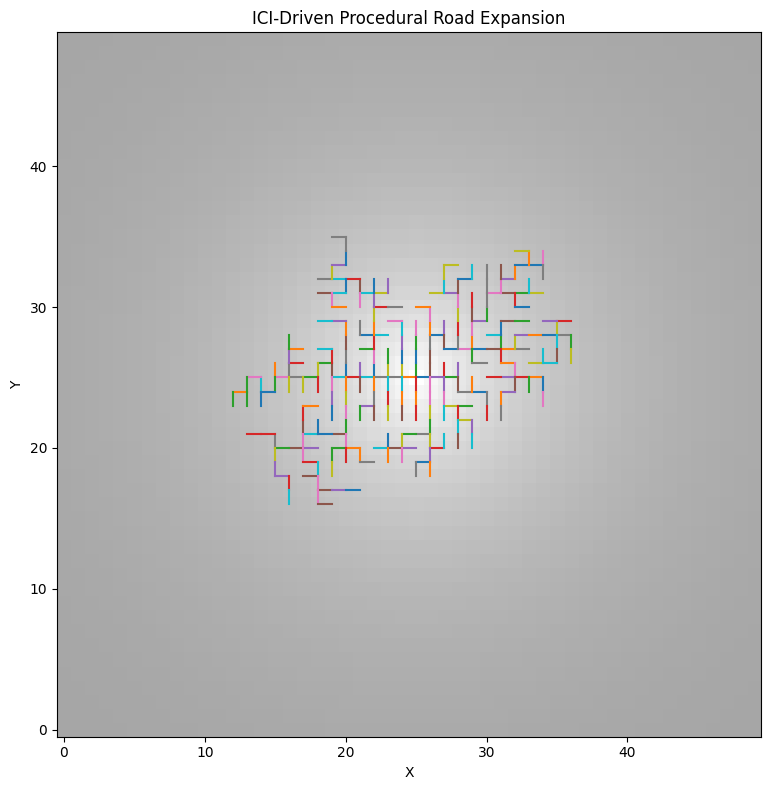

In [11]:
plot_road_graph(grid, roads)

# PART B: GEO-GROUNDED ASTANA INTEGRATION

STEP B1: GEO IMPORTS - ASTANA GIS INGESTION

In [12]:
pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 4.5 MB/s eta 0:00:00


In [13]:
# Geospatial stack

import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import networkx as nx

STEP B2: DEFINE CITY QUERY

In [14]:
place_name = "Astana, Kazakhstan"

STEP B3: DOWNLOAD REAL ROAD NETWORK

In [15]:
G_real = ox.graph_from_place(
    place_name,
    network_type="drive"
)

This is the first Earth-anchored infrastructure graph.

STEP B4: VISUALIZE ASTANA ROAD NETWORK

Now we render the actual city geometry.

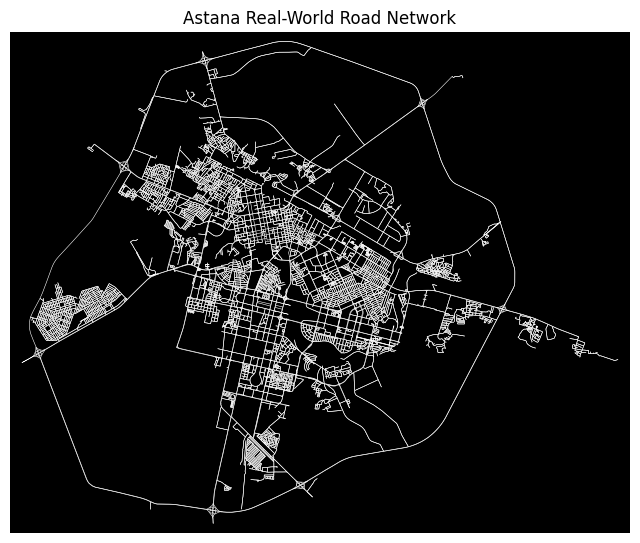

In [16]:
fig, ax = ox.plot_graph(
    G_real,
    bgcolor="black",
    node_size=0,
    edge_linewidth=0.4,
    edge_color="white",
    show=False,
    close=False
)

plt.title("Astana Real-World Road Network")

plt.show()

We immediately notice:

arterial hierarchy
irregular topology
district asymmetry
radial + grid hybrids
urban complexity

Reality contains:

embedded Infrastructure Influence Field.

STEP B5: CONVERT GRAPH TO GEODATAFRAMES

This is critical for overlays and future GIS operations.

In [17]:
nodes_real, edges_real = ox.graph_to_gdfs(G_real)

STEP B6: INSPECT REAL INFRASTRUCTURE DATA

In [18]:
edges_real.head()

osmid  \
u         v           key                                                      
250783684 13829597944 0                                           1513824743   
          2439196317  0                              [535921238, 1456296679]   
          2439196353  0    [1459982272, 1459982256, 1459982257, 145998225...   
250783685 1238541549  0                                            723051233   
          4725269857  0                                            139537456   

                                  highway  oneway reversed      length lanes  \
u         v           key                                                      
250783684 13829597944 0    secondary_link   False     True   11.064829   NaN   
          2439196317  0         secondary    True    False  192.230344     2   
          2439196353  0       residential   False     True  240.520390     4   
250783685 1238541549  0         secondary    True    False    6.805185   NaN   
          4725269857  0         secondary    True    False  253.469827     2   

                          maxspeed                    name  \
u         v           key                                    
250783684 13829597944 0        NaN                     NaN   
          2439196317  0         60  Қабанбай Батыр даңғылы   
          2439196353  0        NaN   Ғабдолла Тоқай көшесі   
250783685 1238541549  0        NaN         Сарайшық көшесі   
          4725269857  0         60  Қабанбай Батыр даңғылы   

                                                                    geometry  \
u         v           key                                                      
250783684 13829597944 0    LINESTRING (71.41203 51.12007, 71.41219 51.12004)   
          2439196317  0    LINESTRING (71.41203 51.12007, 71.41202 51.119...   
          2439196353  0    LINESTRING (71.41203 51.12007, 71.41175 51.120...   
250783685 1238541549  0     LINESTRING (71.41571 51.13645, 71.4158 51.13643)   
          4725269857  0    LINESTRING (71.41571 51.13645, 71.4156 51.1362...   

                           ref bridge tunnel width junction access service  
u         v           key                                                   
250783684 13829597944 0    NaN    NaN    NaN   NaN      NaN    NaN     NaN  
          2439196317  0    NaN    NaN    NaN   NaN      NaN    NaN     NaN  
          2439196353  0    NaN    NaN    NaN   NaN      NaN    NaN     NaN  
250783685 1238541549  0    NaN    NaN    NaN   NaN      NaN    NaN     NaN  
          4725269857  0    NaN    NaN    NaN   NaN      NaN    NaN     NaN

In [19]:
nodes_real.head()

,y,x,street_count,highway,ref,railway,geometry
osmid,,,,,,,
250783684,51.120065,71.412031,4,NaN,NaN,NaN,POINT (71.41203 51.12007)
250783685,51.136447,71.415708,4,NaN,NaN,NaN,POINT (71.41571 51.13645)
259015127,51.181545,71.374197,4,traffic_signals,NaN,NaN,POINT (71.3742 51.18155)
259015326,51.204364,71.310499,3,NaN,NaN,NaN,POINT (71.3105 51.20436)
259016376,51.121374,71.648200,4,NaN,NaN,NaN,POINT (71.6482 51.12137)


STEP B7: GEO-ALIGNED ICI FIELD
Objective

Create a real-world spatial intensity field aligned to:

Astana geometry,
real coordinates,
real extents.

This is still synthetic in signal generation, but geographically grounded

STEP B7.1: EXTRACT CITY BOUNDING BOX

In [20]:
minx, miny, maxx, maxy = edges_real.total_bounds

print("Astana Bounds:")
print(minx, miny, maxx, maxy)

Astana Bounds:
71.2223231 51.0151123 71.7164808 51.2658111


The actual geographic extent of Astana roads:

longitude range
latitude range

This becomes our simulation domain

STEP B7.2: CREATE GEO-GRID

We now replace arbitrary synthetic grid with Earth-aligned spatial raster.

In [21]:
grid_size = 200

x = np.linspace(minx, maxx, grid_size)
y = np.linspace(miny, maxy, grid_size)

X, Y = np.meshgrid(x, y)

We now have a geo-referenced raster lattice over Astana.

This is effectively the substrate of future ICI intelligence

STEP B7.3 — DEFINE FIRST GEO-ALIGNED ICI FIELD

For now:
we still use a synthetic attractor,
BUT:
it exists in real geographic space.

In [22]:
# Define synthetic city center attractor

center_x = (minx + maxx) / 2
center_y = (miny + maxy) / 2

distance = np.sqrt(
    (X - center_x)**2 +
    (Y - center_y)**2
)

ICI_real = np.exp(
    -distance / (distance.max() / 3)
)

What This Represents

Currently:

synthetic urban intensity,
projected onto real Astana geography.

Later:
this becomes:

EO-derived construction intensity,
infrastructure condition,
accessibility pressure,
or growth dynamics.

STEP B7.4: VISUALIZE REAL ICI OVER ASTANA

Now comes the first true geo-intelligence visualization.

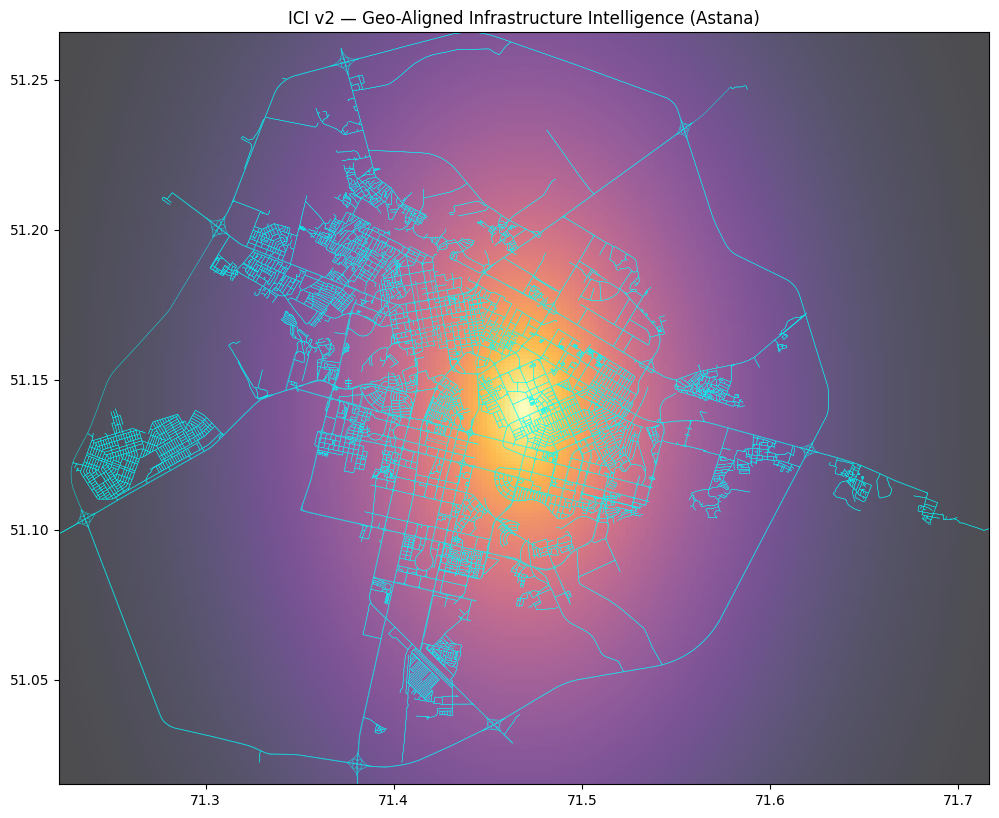

In [23]:
fig, ax = plt.subplots(figsize=(12, 12))

# Plot ICI field
ax.imshow(
    ICI_real,
    extent=(minx, maxx, miny, maxy),
    origin="lower",
    cmap="inferno",
    alpha=0.7
)

# Plot roads
edges_real.plot(
    ax=ax,
    linewidth=0.3,
    color="cyan"
)

ax.set_title(
    "ICI v2 — Geo-Aligned Infrastructure Intelligence (Astana)"
)

plt.show()

THIS Is A Major Milestone

You are now seeing:

Infrastructure intelligence over real Earth geometry.

Not:

arbitrary grids,
not fictional cities,
not pure GIS,
not pure simulation.

This is the beginning of:

geospatial infrastructure cognition.
What You Should Observe

You should now see:

real Astana roads,
overlaid with spatial intensity structure,
embedded into actual city topology.

Even though the field is still synthetic:
the system now has:

coordinate integrity.

That changes everything.

STEP B7.5: ROAD ACCESSIBILITY SAMPLING

Now we begin connecting:

infrastructure
to
intensity.

In [24]:
# Sample a subset of roads

sample_edges = edges_real.sample(500)

sample_edges.head()

,,,osmid,highway,oneway,reversed,length,lanes,maxspeed,name,geometry,ref,bridge,tunnel,width,junction,access,service
u,v,key,,,,,,,,,,,,,,,,
1774356813,259996449,0,453658297,secondary,True,False,10.145105,3,60,Александр Кравцов көшесі,"LINESTRING (71.45369 51.15514, 71.45364 51.15523)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2862602088,2862602086,0,282333800,residential,False,False,93.899689,NaN,NaN,NaN,"LINESTRING (71.28095 51.12374, 71.27977 51.12333)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2862602094,10666252431,0,578437853,residential,False,True,287.795070,NaN,NaN,улица Байтерек,"LINESTRING (71.27547 51.12437, 71.27503 51.124...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
269925082,292204464,0,609765365,residential,False,False,111.509121,NaN,NaN,улица Ушкултай Субханбердина,"LINESTRING (71.51605 51.14408, 71.51695 51.143...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
5787559218,5754535106,0,611248338,secondary,True,False,383.837574,3,NaN,Сарайшық көшесі,"LINESTRING (71.41576 51.13654, 71.41556 51.136...",NaN,NaN,NaN,NaN,NaN,NaN,NaN


we now will:

compute ICI values near roads,
derive accessibility/intensity relationships,
rank corridors,
simulate interventions.

This is the beginning of infrastructure semantics.
After this we can begin: ROAD INTELLIGENCE LAYER

Meaning:

corridor importance
accessibility fields
density interaction
intervention simulation

This is where:
the “decision intelligence” aspect truly begins emerging.

STEP B8: ROAD INTELLIGENCE LAYER

Objective

Compute:

corridor importance,
connectivity significance,
and proto-accessibility structure
from the real Astana road network.

This is our first infrastructure cognition layer.

STEP B8.1: COMPUTE ROAD CENTRALITY

In [ ]:
# Compute node betweenness centrality

centrality = nx.betweenness_centrality(
    G_real,
    k=500,
    normalized=True,
    seed=42
)

What This Represents

Betweenness centrality approximates:

corridor importance,
traffic mediation,
strategic connectivity,
urban flow significance.

In transportation systems language:

High centrality⇒high network influence

This is already:

transportation intelligence.

STEP B8.2: ATTACH CENTRALITY TO NODES

In [ ]:
nodes_real["centrality"] = (
    nodes_real.index.map(centrality)
)

STEP B8.3: VISUALIZE ROAD INTELLIGENCE

Now render strategic corridor structure.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))

edges_real.plot(
    ax=ax,
    linewidth=0.3,
    color="lightgray"
)

nodes_real.plot(
    ax=ax,
    column="centrality",
    cmap="inferno",
    markersize=5,
    legend=True
)

ax.set_title(
    "Astana Road Network — Strategic Corridor Centrality"
)

plt.show()

transportation semantics emerge from the infrastructure graph.

Not mere geometry,
but strategic flow structure.

This is directly relevant to transportation systems,
urban accessibility,
and infrastructure planning.
We should see:

arterial corridors highlighted,
strategic intersections emerge,
central urban mediators appear,
network hierarchy become visible.

This is effectively:

latent transportation structure.

STEP B8.4 IDENTIFY TOP STRATEGIC NODES

In [ ]:
top_nodes = nodes_real.sort_values(
    by="centrality",
    ascending=False
).head(10)

top_nodes[["centrality"]]

We are now identifying:

infrastructure leverage points.

Potentially:

mobility bottlenecks,
strategic intersections,
future congestion zones,
intervention candidates.

It is beginning to infer structural significance from topology.

That is the beginning of decision-support intelligence.

# ICI v2 STEP B9
ACCESSIBILITY FIELD GENERATION

Influence propagates spatially,
connectivity gradients emerge,
infrastructure pressure fields form,
and interventions gain measurable impact.

That is where “what-if” vision begins becoming operational.

This is one of the most important conceptual transitions so far.

We are moving from static infrastructure representation to propagated infrastructure influence.

Meaning:
roads no longer merely exist —
they exert spatial effect.

This is foundational for:

transportation systems,
accessibility analysis,
infrastructure pressure,
and intervention reasoning.
Core Concept

We want to approximate:

Accessibility(x,y)

Meaning:

“How strongly connected is this spatial location to important infrastructure?”

This is a central concept in:

urban planning,
transportation systems,
land-use economics,
and infrastructure development.

STEP B9.1 EXTRACT NODE COORDINATES

In [ ]:
node_x = nodes_real.geometry.x.values
node_y = nodes_real.geometry.y.values

node_centrality = (
    nodes_real["centrality"]
    .fillna(0)
    .values
)

We now have:

real spatial coordinates
and strategic importance values

for the actual Astana network.

STEP B9.2 INITIALIZE ACCESSIBILITY FIELD

In [ ]:
accessibility_field = np.zeros_like(X)

Interpretation

This raster will accumulate:

infrastructure influence,
connectivity propagation,
spatial accessibility gradients.

STEP B9.3 PROPAGATE ROAD INFLUENCE/ACCESSIBILITY

In [ ]:
for x_node, y_node, c in zip(
    node_x,
    node_y,
    node_centrality
):

    dist = np.sqrt(
        (X - x_node)**2 +
        (Y - y_node)**2
    )

    influence = c * np.exp(
        -dist / ((maxx - minx) / 20)
    )

    accessibility_field += influence

Each strategic node:

emits spatial influence,
decaying with distance.

Conceptually:

highly connected corridors
shape surrounding accessibility.

This is:

proto-transportation field modeling.

STEP B9.4 NORMALIZE FIELD

In [ ]:
accessibility_field = (
    accessibility_field /
    accessibility_field.max()
)

STEP B9.5: VISUALIZE ACCESSIBILITY FIELD

Now render the first real accessibility landscape of Astana.

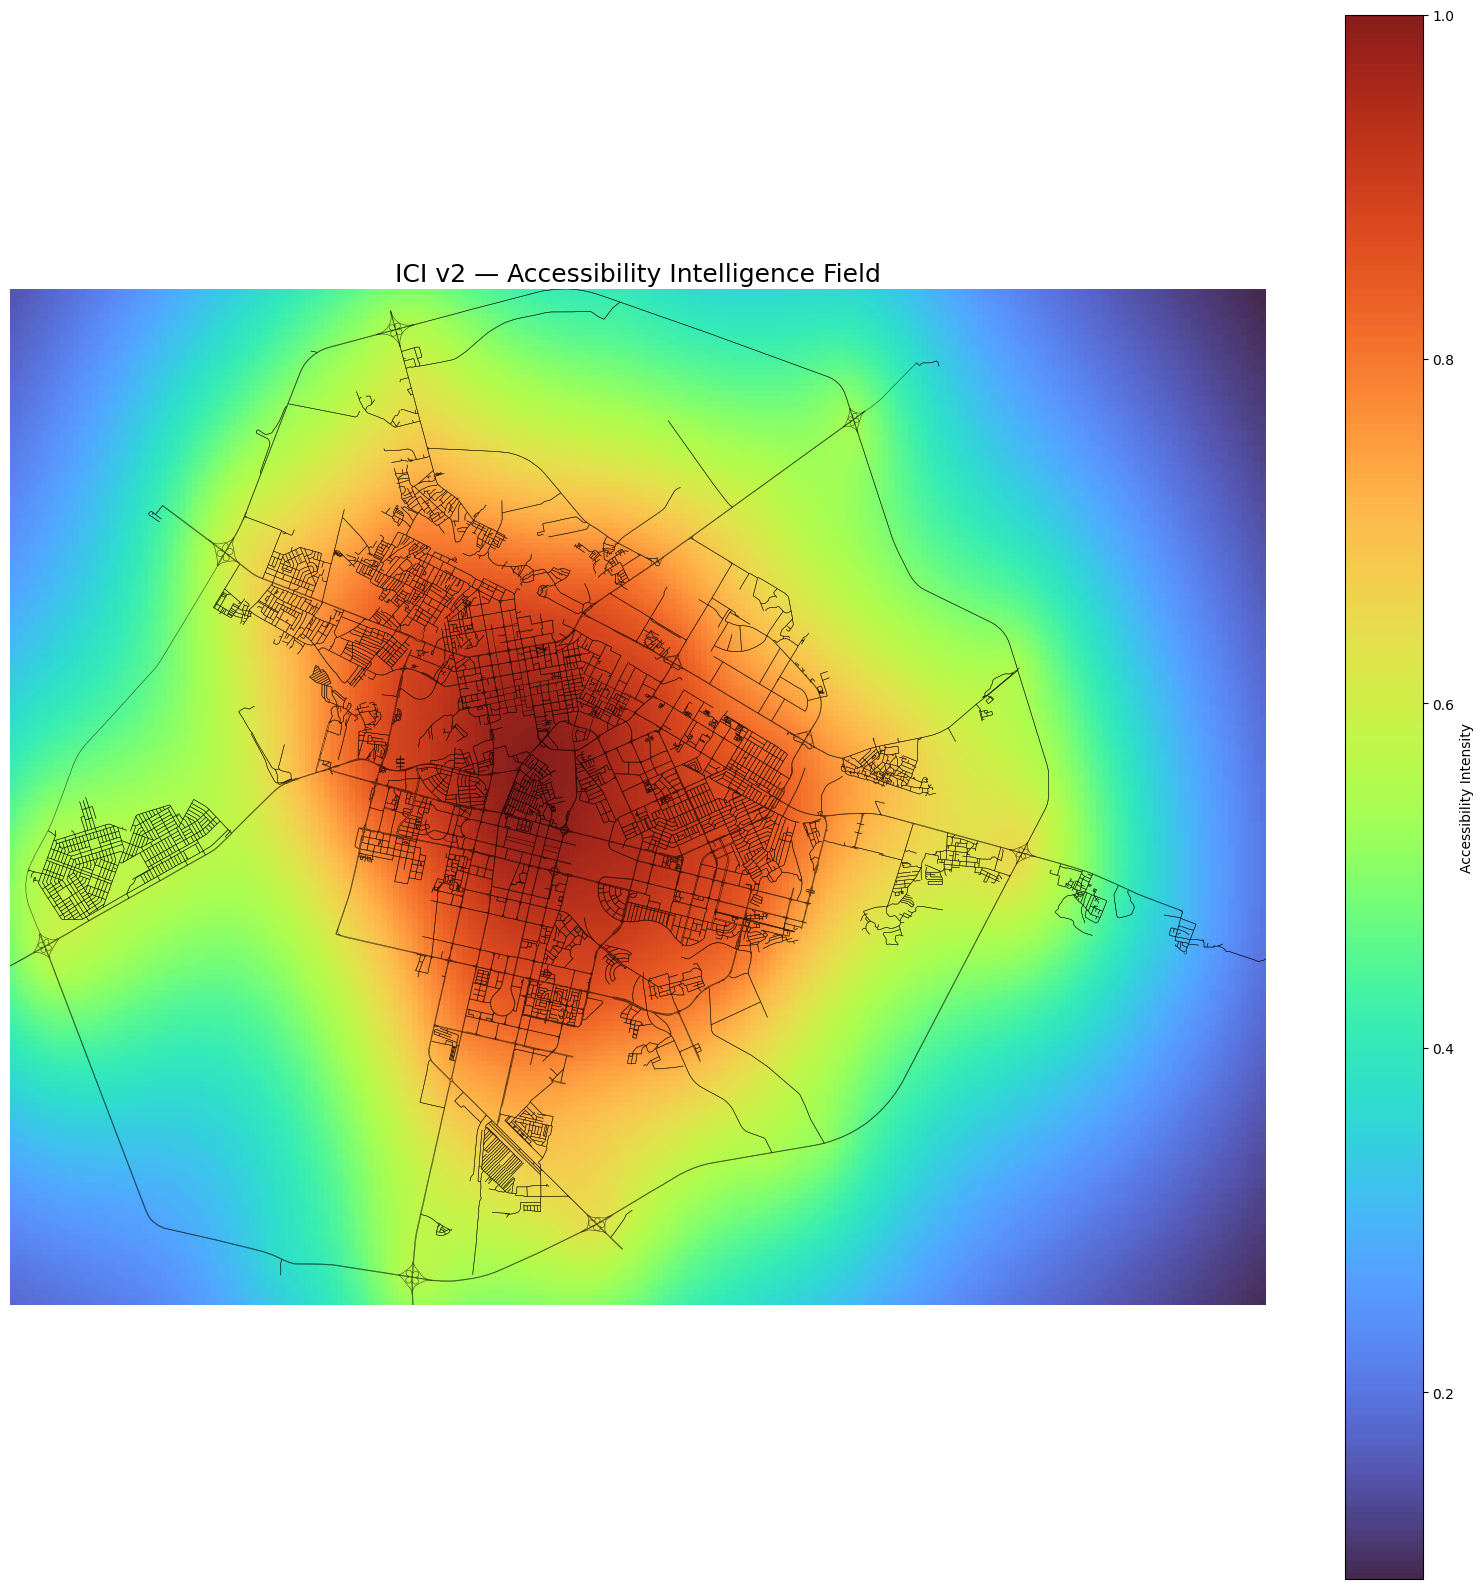

In [ ]:
fig, ax = plt.subplots(figsize=(16, 16))

# Stronger normalized accessibility field
field_display = np.power(
    accessibility_field,
    0.35
)

# Heatmap
im = ax.imshow(
    field_display,
    extent=(minx, maxx, miny, maxy),
    origin="lower",
    cmap="turbo",
    alpha=0.9
)

# Roads overlay
edges_real.plot(
    ax=ax,
    linewidth=0.4,
    color="black",
    alpha=0.7
)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Accessibility Intensity")

ax.set_title(
    "ICI v2 — Accessibility Intelligence Field",
    fontsize=18
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

STEP B9.6 COMBINED ICI + ACCESSIBILITY

Now fuse:

infrastructure intensity
with:
transportation accessibility.

In [ ]:
combined_field = (
    0.5 * ICI_real +
    0.5 * accessibility_field
)

Now our system begins integrating:

growth pressure
with
transportation structure.

This is foundational for:

intervention logic,
infrastructure prioritization,
urban expansion reasoning.

ZOOM INTO CENTRAL ASTANA

Full-city rendering is too broad initially.

We need:

local spatial inspection.

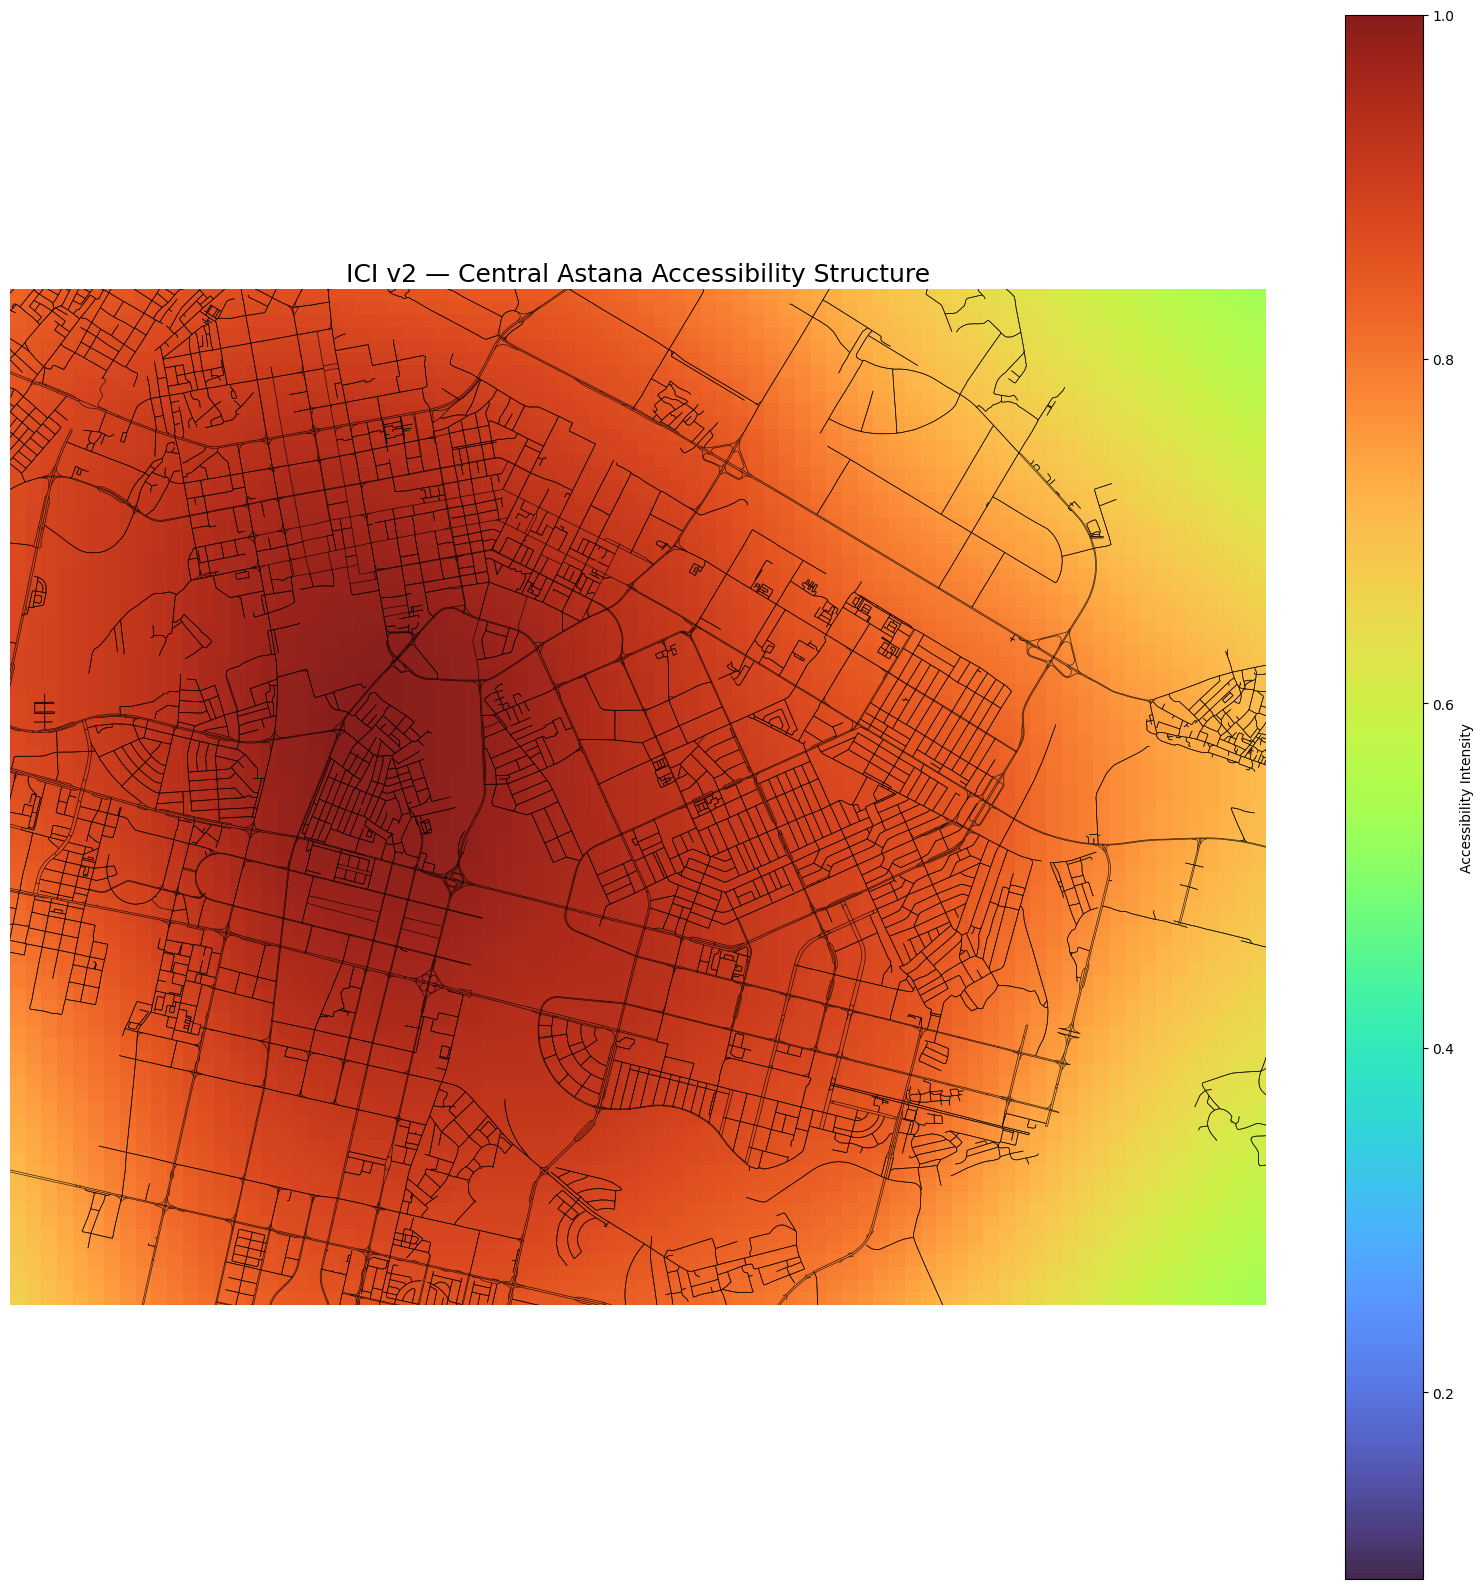

In [ ]:
fig, ax = plt.subplots(figsize=(16, 16))

field_display = np.power(
    accessibility_field,
    0.35
)

im = ax.imshow(
    field_display,
    extent=(minx, maxx, miny, maxy),
    origin="lower",
    cmap="turbo",
    alpha=0.9
)

edges_real.plot(
    ax=ax,
    linewidth=0.5,
    color="black",
    alpha=0.8
)

# Zoom toward city center
x_margin = (maxx - minx) * 0.2
y_margin = (maxy - miny) * 0.2

ax.set_xlim(
    center_x - x_margin,
    center_x + x_margin
)

ax.set_ylim(
    center_y - y_margin,
    center_y + y_margin
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Accessibility Intensity")

ax.set_title(
    "ICI v2 — Central Astana Accessibility Structure",
    fontsize=18
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

STEP B10
INTERVENTION SIMULATION LAYER

Objective

Simulate:

infrastructure interventions,
accessibility modifications,
and resulting Infrastructure Interaction Field shifts.

This is the first operational version of your:

“what-if” framework.
Important Clarification

We are NOT yet doing realistic traffic engineering,
transport assignment,
microsimulation, or socioeconomic prediction.
We are doing spatial intervention propagation.

STEP B10.1 DEFINE INTERVENTION POINT

We first create a hypothetical new infrastructure intervention.

Example:

new arterial road,
transit hub,
accessibility investment,
logistics corridor.

In [ ]:
# Example intervention location
# (slightly east of city center)

intervention_x = center_x + ((maxx - minx) * 0.08)
intervention_y = center_y

This becomes a hypothetical infrastructure investment point.

Later this could come from:

user clicks,
UI interaction,
scenario selection,
optimization outputs.

STEP B10.2 CREATE INTERVENTION FIELD

Now propagate influence from the intervention.

In [ ]:
dist_intervention = np.sqrt(
    (X - intervention_x)**2 +
    (Y - intervention_y)**2
)

intervention_field = np.exp(
    -dist_intervention / ((maxx - minx) / 15)
)

What This Represents

Conceptually:

Intervention Influence(x,y)

Meaning:

improved accessibility,
infrastructure investment impact,
enhanced connectivity potential.

STEP B10.3 COMBINE WITH EXISTING INTELLIGENCE

In [ ]:
post_intervention_field = (
    combined_field +
    0.4 * intervention_field
)

post_intervention_field = (
    post_intervention_field /
    post_intervention_field.max()
)

Interpretation: We are now computing:

Infrastructure Interaction Field
after
	​

=Infrastructure Interaction Field
before
	​

+Infrastructure Intervention

This is the beginning of:

scenario-driven infrastructure reasoning.

STEP B10.4 VISUALIZE PRE VS POST INTERVENTION

Now we render the change.

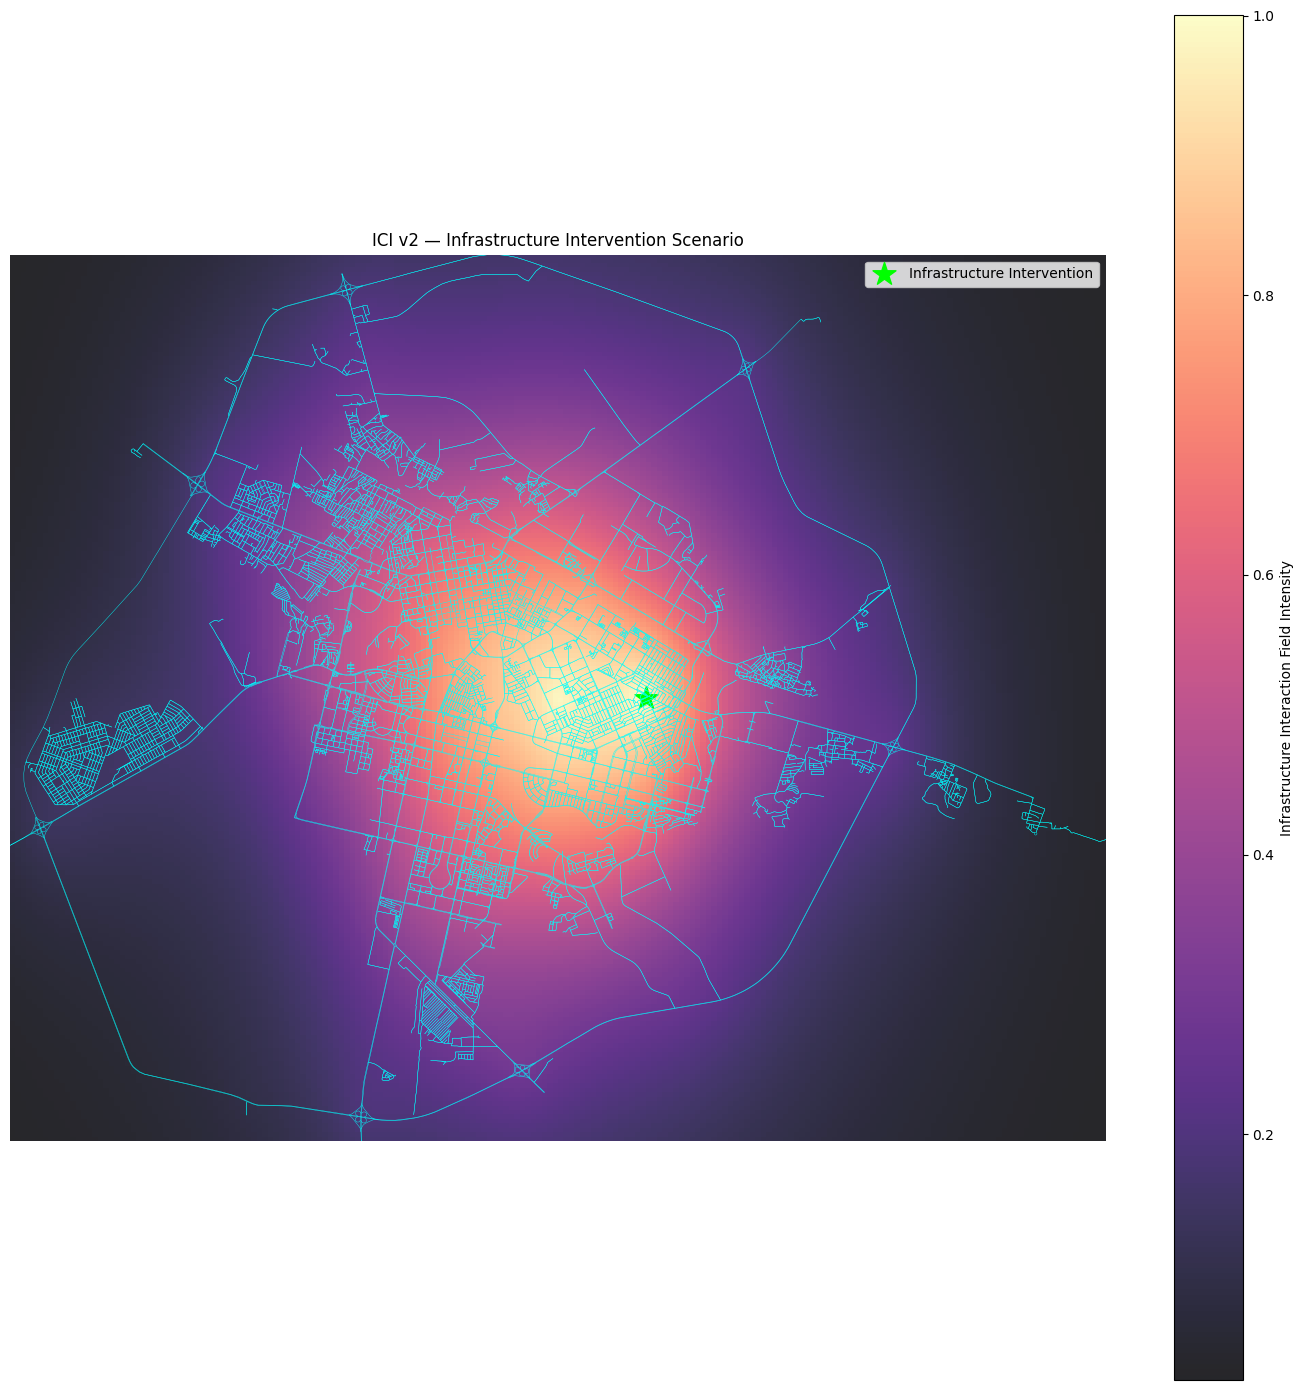

In [ ]:
fig, ax = plt.subplots(figsize=(14, 14))

# Post-intervention field
im = ax.imshow(
    post_intervention_field,
    extent=(minx, maxx, miny, maxy),
    origin="lower",
    cmap="magma",
    alpha=0.85
)

# Roads
edges_real.plot(
    ax=ax,
    linewidth=0.3,
    color="cyan"
)

# Intervention marker
ax.scatter(
    intervention_x,
    intervention_y,
    s=300,
    c="lime",
    marker="*",
    label="Infrastructure Intervention"
)

ax.legend()

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Infrastructure Interaction Field Intensity")

ax.set_title(
    "ICI v2 — Infrastructure Intervention Scenario"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

STEP B11 COMPARATIVE VISUALIZATION LAYER
Objective

Create:

side-by-side scenario comparison,
interpretable delta rendering,
clearer intervention communication.

This is your first:

executive-facing visualization refinement layer.